# Análise Exploratória — clean_data.csv

Este notebook analisa os dados **após** a limpeza realizada por `data_sanitization.py`.

Objetivo: entender distribuições, valores ausentes, correlações e o desbalanceamento do TARGET antes de construir a ABT.

In [1]:
import pathlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

# Sobe um nível: de Analysis/ para a raiz do projeto (CreditRisk/)
PROJECT_ROOT = pathlib.Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
    
#sys.path.insert(0, os.path.abspath('.'))
from config import CLEAN_DATA_PATH, TARGET_COLUMN, ID_COLUMN

sns.set_theme(style='whitegrid')
df = pd.read_csv(CLEAN_DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (356251, 242)


,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,HOUSETYPE_MODE_terraced_house,WALLSMATERIAL_MODE_Block,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,WALLSMATERIAL_MODE_Stone_brick,WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_No,EMERGENCYSTATE_MODE_Yes
0,100002,1.0,0,0,0,0,202500.0,406597.5,24700.5,351000.0,...,False,False,False,False,False,False,True,False,True,False
1,100003,0.0,1,0,1,0,270000.0,1293502.5,35698.5,1129500.0,...,False,True,False,False,False,False,False,False,True,False
2,100004,0.0,0,1,0,0,67500.0,135000.0,6750.0,135000.0,...,False,False,False,False,False,False,False,False,False,False
3,100006,0.0,1,0,0,0,135000.0,312682.5,29686.5,297000.0,...,False,False,False,False,False,False,False,False,False,False
4,100007,0.0,0,0,0,0,121500.0,513000.0,21865.5,513000.0,...,False,False,False,False,False,False,False,False,False,False


## 1. Visão geral do dataset

In [2]:
# Tipos de dados e valores ausentes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
summary = pd.DataFrame({'missing': missing, 'missing_%': missing_pct})
summary[summary['missing'] > 0].sort_values('missing_%', ascending=False).head(20)

,missing,missing_%
COMMONAREA_MODE,248357,69.71
COMMONAREA_MEDI,248357,69.71
COMMONAREA_AVG,248357,69.71
NONLIVINGAPARTMENTS_AVG,246859,69.29
NONLIVINGAPARTMENTS_MODE,246859,69.29
NONLIVINGAPARTMENTS_MEDI,246859,69.29
LIVINGAPARTMENTS_AVG,242977,68.20
LIVINGAPARTMENTS_MEDI,242977,68.20
LIVINGAPARTMENTS_MODE,242977,68.20
FLOORSMIN_MODE,241106,67.68


## 2. Distribuição do TARGET

O dataset é desbalanceado: ~8% de inadimplentes (TARGET=1) vs ~92% adimplentes (TARGET=0).
Isso impacta a escolha da métrica (usamos AUC-ROC) e pode exigir StratifiedKFold.

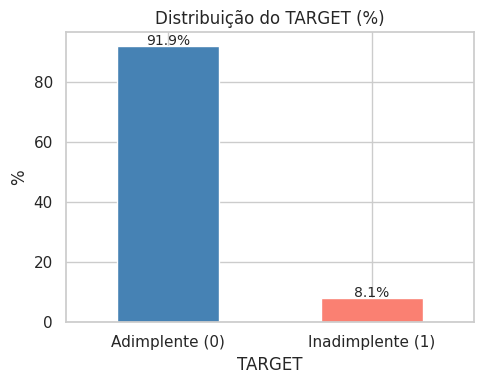

TARGET
0.0    91.927013
1.0     8.072987
Name: proportion, dtype: float64


In [3]:
train = df[df[TARGET_COLUMN].notnull()]
target_counts = train[TARGET_COLUMN].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 4))
target_counts.plot.bar(ax=ax, color=['steelblue', 'salmon'])
ax.set_title('Distribuição do TARGET (%)')
ax.set_xticklabels(['Adimplente (0)', 'Inadimplente (1)'], rotation=0)
ax.set_ylabel('%')
for i, v in enumerate(target_counts):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()
print(target_counts)

## 3. Distribuição de variáveis numéricas-chave

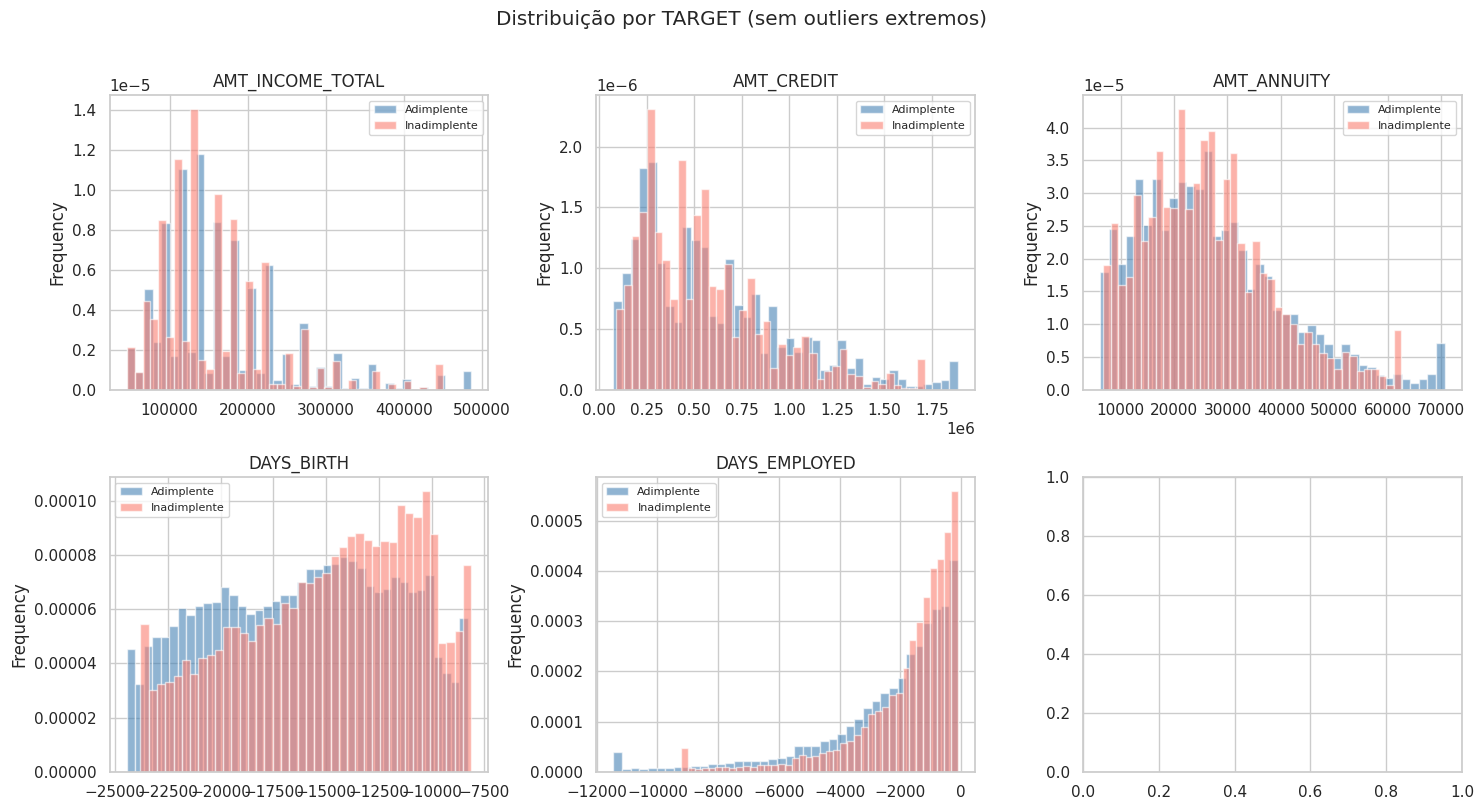

In [4]:
num_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
            'DAYS_BIRTH', 'DAYS_EMPLOYED', 'PAYMENT_RATE']

num_cols = [c for c in num_cols if c in df.columns]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), num_cols):
    for target_val, color, label in [(0, 'steelblue', 'Adimplente'), (1, 'salmon', 'Inadimplente')]:
        subset = train[train[TARGET_COLUMN] == target_val][col].dropna()
        subset.clip(subset.quantile(0.01), subset.quantile(0.99)).plot.hist(
            ax=ax, bins=40, alpha=0.6, color=color, label=label, density=True
        )
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle('Distribuição por TARGET (sem outliers extremos)', y=1.01)
plt.tight_layout()
plt.show()

## 4. Correlação das features numéricas com o TARGET

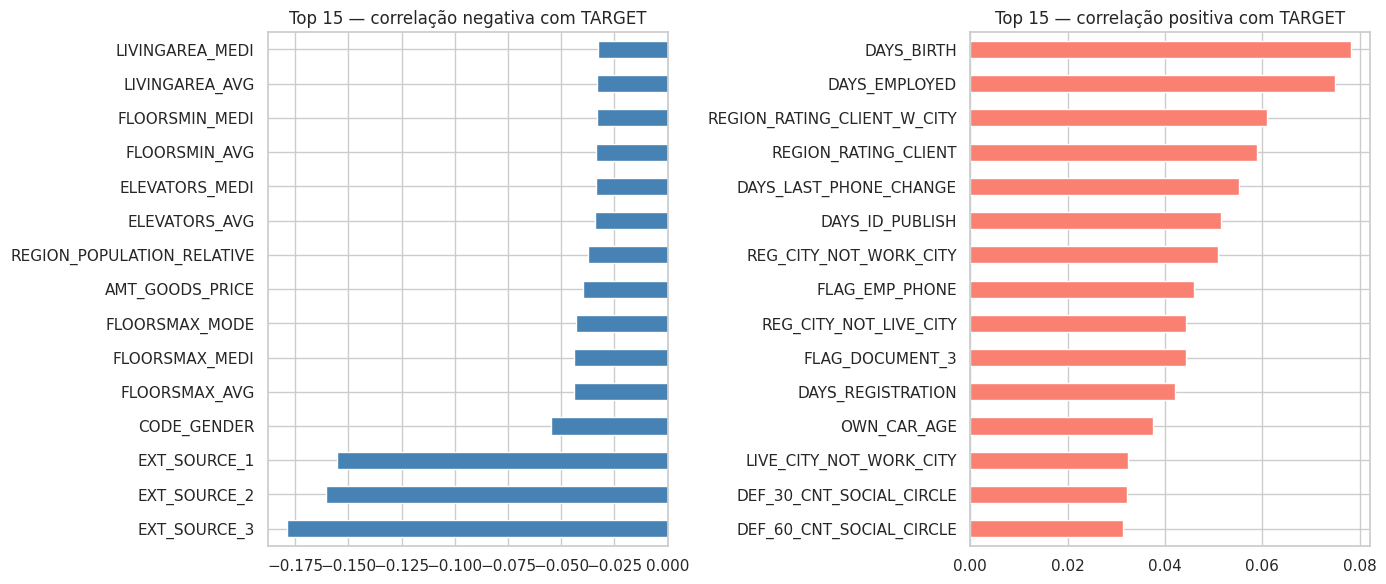

In [5]:
numeric_df = train.select_dtypes(include=[np.number])
correlations = numeric_df.corr()[TARGET_COLUMN].drop(TARGET_COLUMN)
correlations = correlations.dropna().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Features com correlação mais negativa (protetoras contra default)
correlations.head(15).plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 — correlação negativa com TARGET')

# Features com correlação mais positiva (indicadores de risco)
correlations.tail(15).plot.barh(ax=axes[1], color='salmon')
axes[1].set_title('Top 15 — correlação positiva com TARGET')

plt.tight_layout()
plt.show()

## 5. Heatmap de correlação entre features derivadas

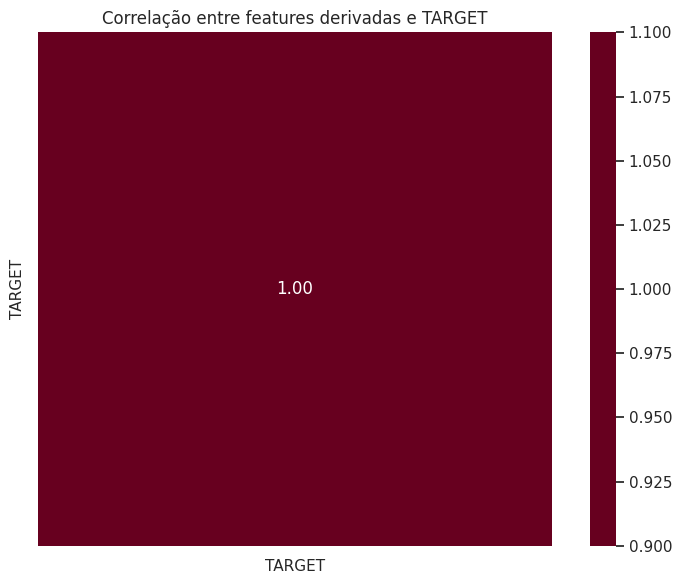

In [6]:
derived = ['DAYS_EMPLOYED_PERC', 'INCOME_CREDIT_PERC', 'INCOME_PER_PERSON',
           'ANNUITY_INCOME_PERC', 'PAYMENT_RATE', TARGET_COLUMN]
derived = [c for c in derived if c in train.columns]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(train[derived].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True)
ax.set_title('Correlação entre features derivadas e TARGET')
plt.tight_layout()
plt.show()